# Chapter 1: Manifolds and Smooth Maps

**Source Span.** `Differential Topology.pdf` printed pages `1-56`, with section landmarks on definitions, derivatives and tangent spaces, the inverse function theorem, immersions, submersions, transversality, homotopy and stability, Sard's theorem, Morse functions, and embedding manifolds in Euclidean space.

**Chapter Goal.** Learn to read a smooth map by looking at its local models: charts make a manifold calculable, derivatives move tangent vectors, rank conditions split maps into immersions and submersions, transversality turns inverse images into manifolds, Sard explains why regular values are abundant, and embedding theorems explain why an abstract manifold can be studied inside a sufficiently large Euclidean space.

This chapter is the gateway into the whole course, so the notebook treats every major definition as something inspectable. A chart is shown as a coordinate window, not as a slogan. A tangent map is a matrix acting on a small basis. The inverse and submersion theorems become local canonical forms with rank checks. Transversality is represented by visible tangent directions and a codimension count. Sard's theorem and Morse functions appear as a computational diagnostic: critical values are exceptional, while regular level sets are stable. The embedding section is handled through projection experiments that show how collisions appear in too few dimensions and disappear when enough coordinates are retained.

The source is used here for orientation and terminology only. The examples, diagrams, code, and explanatory prose are original, compact models chosen to expose the same geometry without reproducing the book's text or figures.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate the Differential Topology course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

UNIT_KEY = "chapter-01-manifolds-and-smooth-maps"
UNIT_TITLE = "Manifolds and Smooth Maps"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"
TRACKED_ARTIFACTS = []
np.set_printoptions(precision=4, suppress=True)
print(f"Book root: {BOOK_ROOT}")


Book root: D:\Geometry\Differential-Topology


## Visual Storyboard

1. **Chart and tangent-plane microscope.** A smooth surface patch is viewed through a coordinate grid. At one point the two chart-coordinate directions become tangent vectors in Euclidean space, and the rank of the Jacobian is checked numerically.
2. **Rank theorem triad.** Three local models sit side by side: an immersion, a submersion, and a transverse intersection. The point is not to memorize names but to inspect which derivative directions survive and how the preimage dimension changes.
3. **Sard and Morse diagnostic.** A scalar map on the plane is sampled. The critical value is marked as exceptional, regular levels are drawn as stable one-manifolds, and a Morse height function on a circle records isolated nondegenerate critical points.
4. **Embedding and projection lab.** A torus-like parameter grid is projected to fewer coordinates. The notebook counts near-collisions to show why Euclidean realization is not merely decorative: enough coordinates preserve the manifold, too few can fold it over itself.

## Library Routing

| Concept | Representation | Library | Why this route is used | Check |
| --- | --- | --- | --- | --- |
| Charts, tangent spaces, derivative rank | 3D surface patch with tangent basis | Matplotlib + NumPy | The learner needs a durable labeled figure and direct matrix rank computation | `rank(J)=2` and tangent columns match finite differences |
| Immersion, submersion, transversality | Local models and tangent arrows | Matplotlib + SymPy | Exact Jacobians clarify which hypotheses are open rank conditions | symbolic ranks and codimension count |
| Regular values and Morse functions | Level sets and critical markers | Plotly + NumPy | Interactive HTML makes the exceptional value and neighboring regular levels inspectable | gradient norm away from critical point and Hessian determinant at Morse points |
| Embedding theorem intuition | Projection collision counts | Matplotlib + JSON/CSV | A small computational experiment exposes why projections can fail | pairwise near-collision counts decrease with more coordinates |


## Charts, Tangents, And Derivatives

A smooth manifold becomes computational only after we choose local coordinates. The coordinate choice is not the manifold; it is a temporary instrument for measuring points and tangent directions. In the first model below, the chart map sends a rectangle in the `uv`-plane into a curved surface patch in three-dimensional space. The two partial derivative vectors at a selected point form a basis for the tangent plane when the Jacobian has rank two. This is the local picture behind an immersion: nearby parameter directions remain distinguishable after the map.

The derivative is best read as a rule for transporting infinitesimal arrows. A tangent vector in the chart domain is a column vector. Multiplication by the Jacobian produces a tangent vector on the surface. If the columns are independent, a small coordinate square becomes a small parallelogram in the tangent plane. The figure also marks the tangent plane itself, which is a linear approximation and not a replacement for the curved patch. The computational check records the rank, the induced area scale, and a finite-difference residual so the drawing is tied to a measurable claim.


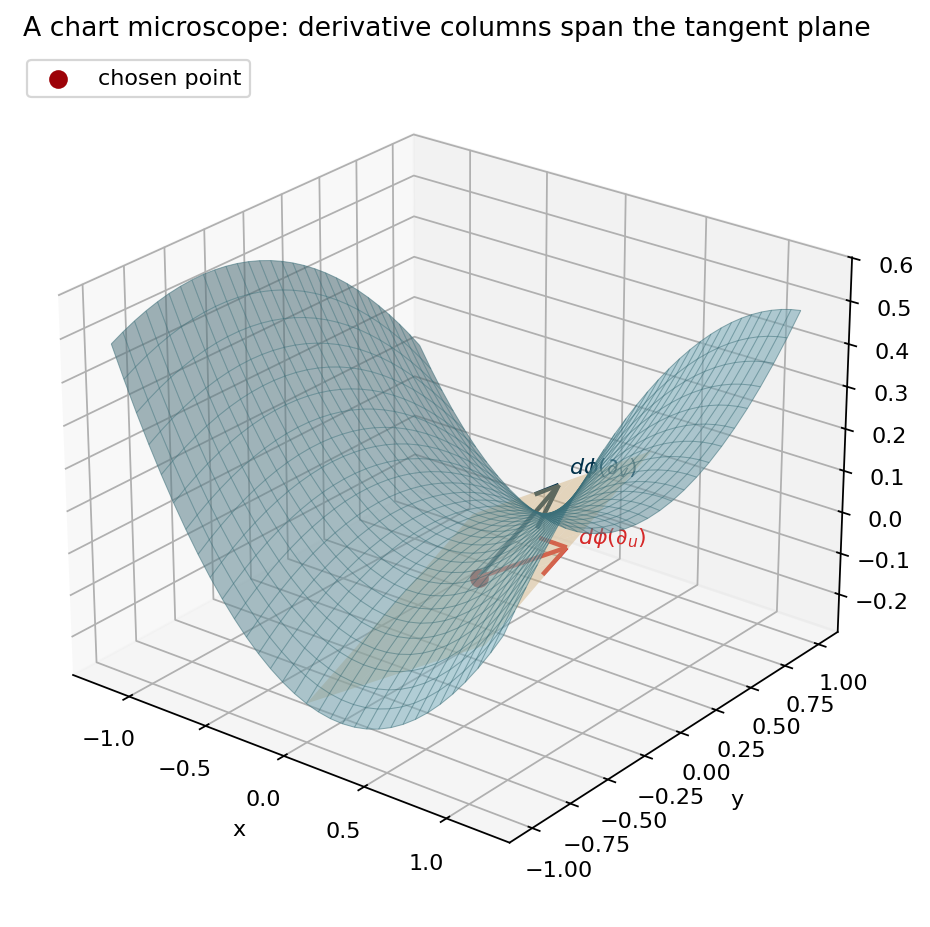

{'jacobian': [[1.0, 0.0], [0.0, 1.0], [0.2625, 0.2075]],
 'rank': 2,
 'area_scale': 1.054496,
 'finite_difference_residual': 3.5000008990483706e-06}

In [2]:
def surface(u, v):
    return np.array([u, v, 0.35 * u**2 - 0.20 * v**2 + 0.15 * u * v])

def jacobian(u, v):
    return np.array([[1.0, 0.0], [0.0, 1.0], [0.70 * u + 0.15 * v, -0.40 * v + 0.15 * u]])

u = np.linspace(-1.2, 1.2, 33)
v = np.linspace(-1.0, 1.0, 29)
U, V = np.meshgrid(u, v)
X = U
Y = V
Z = 0.35 * U**2 - 0.20 * V**2 + 0.15 * U * V
p = np.array([0.45, -0.35])
P = surface(*p)
J = jacobian(*p)
tan_u, tan_v = J[:, 0], J[:, 1]
area_scale = float(np.linalg.norm(np.cross(tan_u, tan_v)))
rank = int(np.linalg.matrix_rank(J, tol=1e-10))

s = np.linspace(-0.55, 0.55, 8)
A, B = np.meshgrid(s, s)
plane = P[:, None, None] + tan_u[:, None, None] * A + tan_v[:, None, None] * B

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, color="#88c0d0", alpha=0.55, linewidth=0, antialiased=True)
ax.plot_wireframe(X, Y, Z, color="#3b6f79", linewidth=0.45, alpha=0.55)
ax.plot_surface(plane[0], plane[1], plane[2], color="#f2cc8f", alpha=0.45, linewidth=0)
ax.scatter([P[0]], [P[1]], [P[2]], color="#9d0208", s=55, label="chosen point")
for vec, label, color in [(tan_u, r"$d\phi(\partial_u)$", "#d62828"), (tan_v, r"$d\phi(\partial_v)$", "#003049")]:
    ax.quiver(P[0], P[1], P[2], vec[0], vec[1], vec[2], length=0.55, normalize=True, color=color, linewidth=2)
    end = P + 0.62 * vec / np.linalg.norm(vec)
    ax.text(end[0], end[1], end[2], label, color=color)
ax.set_title("A chart microscope: derivative columns span the tangent plane")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend(loc="upper left")
ax.view_init(elev=25, azim=-52)
figure_path = save_matplotlib(fig, FIGURES / "chart-tangent-plane-rank.png")
plt.close(fig)
TRACKED_ARTIFACTS.append(figure_path)

fd_u = (surface(*(p + np.array([1e-5, 0]))) - surface(*p)) / 1e-5
fd_residual = float(np.linalg.norm(fd_u - tan_u))
chart_check = {
    "jacobian": J.round(6).tolist(),
    "rank": rank,
    "area_scale": round(area_scale, 6),
    "finite_difference_residual": fd_residual,
}
check_path = save_json(chart_check, CHECKS / "chart-tangent-plane-rank.json")
TRACKED_ARTIFACTS.append(check_path)
display_artifact(figure_path, width=760)
chart_check


## Local Normal Forms: Immersion, Submersion, Transversality

The inverse function theorem says that a full-rank derivative makes a smooth map locally reversible. The immersion and submersion theorems are its two asymmetric descendants. An immersion has injective derivative, so the domain directions remain visible in the target. A submersion has surjective derivative, so its level sets are smooth and have the expected dimension. Transversality packages both ideas into a test for intersections and inverse images: the tangent directions supplied by the map and by the target submanifold must span the ambient tangent space.

The next cell keeps the models deliberately small. An immersed curve has a nonzero velocity vector. A submersion from the plane to the line has nonzero gradient, so regular level sets are curves. A line crossing a circle is transverse except when the line becomes tangent. The symbolic ranks are saved with the figure, which prevents the picture from becoming merely decorative. The learner should check the arrows: the transverse crossing has directions that do not collapse into a single tangent line, while the near-tangent sample warns why hypotheses matter.


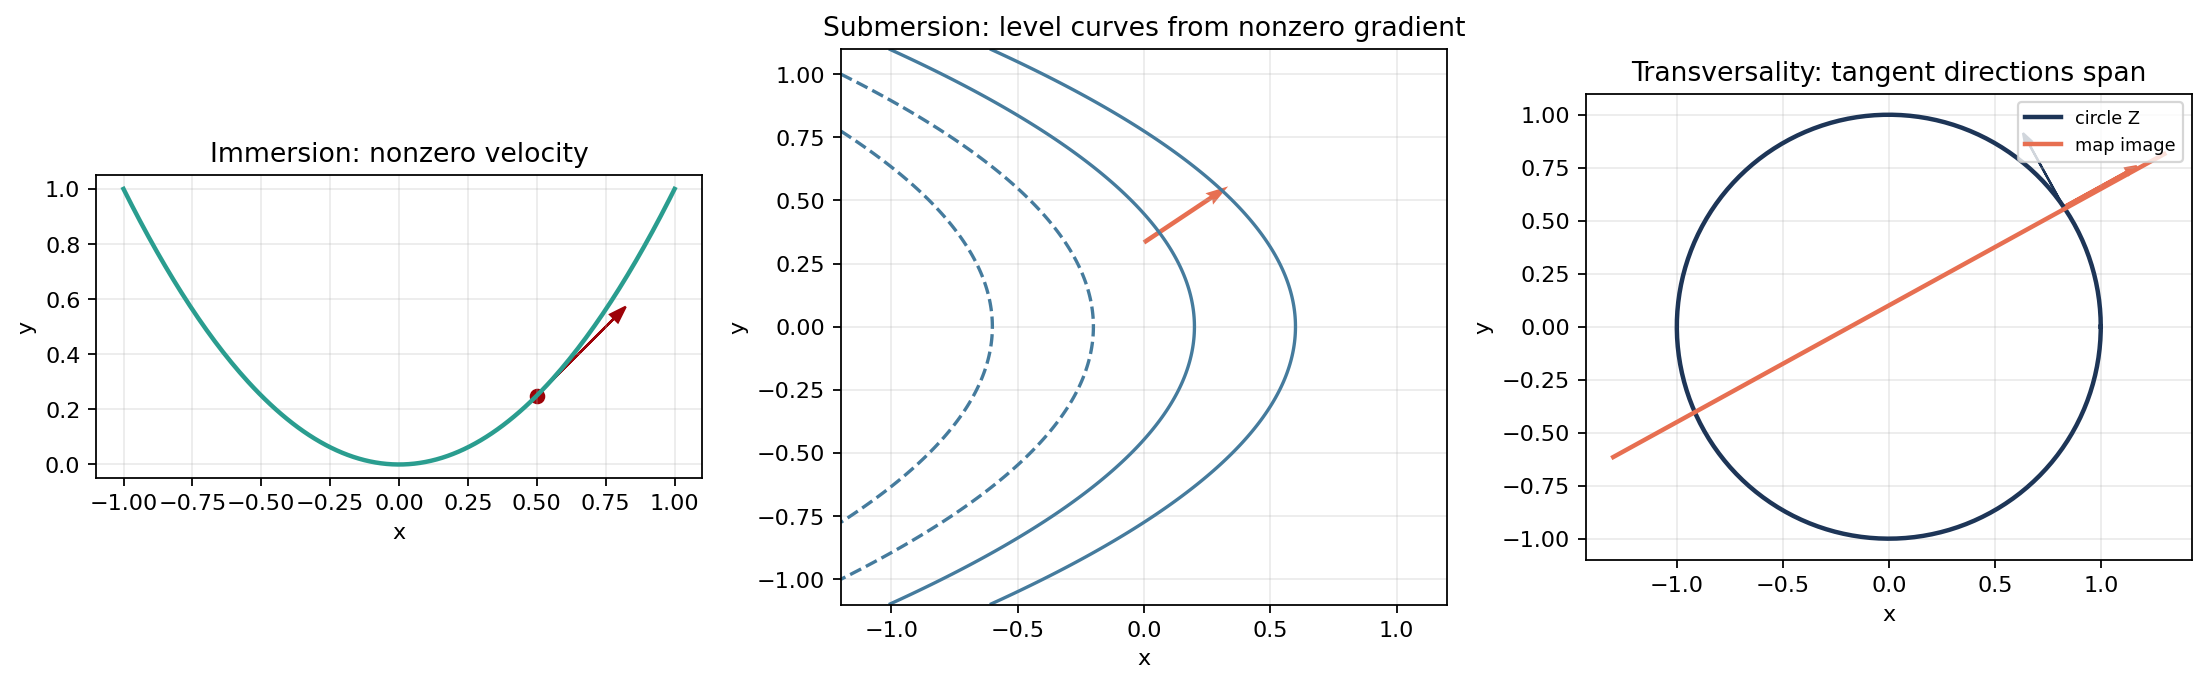

[{'model': 'immersion curve',
  'matrix_or_vector': '[1, 1]',
  'rank_condition': 'velocity nonzero',
  'rank_value': 1},
 {'model': 'submersion scalar map',
  'matrix_or_vector': '[1, 2/3]',
  'rank_condition': 'gradient nonzero',
  'rank_value': 1},
 {'model': 'line-circle crossing',
  'matrix_or_vector': 'two tangent directions in R2',
  'rank_condition': 'determinant nonzero',
  'rank_value': 2}]

In [3]:
t = sp.symbols("t", real=True)
x, y = sp.symbols("x y", real=True)
immersion = sp.Matrix([t, t**2])
velocity = immersion.diff(t).subs(t, sp.Rational(1, 2))
submersion = x + y**2
sub_grad = sp.Matrix([sp.diff(submersion, x), sp.diff(submersion, y)]).subs({x: 0, y: sp.Rational(1, 3)})
line_direction = np.array([1.0, 0.55])
circle_tangent = np.array([-0.55, 1.0])
transverse_det = float(np.linalg.det(np.column_stack([line_direction, circle_tangent])))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
curve_t = np.linspace(-1.0, 1.0, 200)
axes[0].plot(curve_t, curve_t**2, color="#2a9d8f", lw=2)
point = np.array([0.5, 0.25])
vel = np.array([float(velocity[0]), float(velocity[1])])
axes[0].scatter([point[0]], [point[1]], color="#9d0208")
axes[0].arrow(point[0], point[1], 0.28 * vel[0], 0.28 * vel[1], head_width=0.04, color="#9d0208")
axes[0].set_title("Immersion: nonzero velocity")
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(alpha=0.25)

xx = np.linspace(-1.2, 1.2, 220)
yy = np.linspace(-1.1, 1.1, 200)
XX, YY = np.meshgrid(xx, yy)
F = XX + YY**2
axes[1].contour(XX, YY, F, levels=[-0.6, -0.2, 0.2, 0.6], colors="#457b9d")
axes[1].quiver([0], [1/3], [float(sub_grad[0])], [float(sub_grad[1])], color="#e76f51", angles="xy", scale_units="xy", scale=3)
axes[1].set_title("Submersion: level curves from nonzero gradient")
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(alpha=0.25)

theta = np.linspace(0, 2 * np.pi, 300)
axes[2].plot(np.cos(theta), np.sin(theta), color="#1d3557", lw=2, label="circle Z")
line_x = np.linspace(-1.3, 1.3, 100)
axes[2].plot(line_x, 0.55 * line_x + 0.10, color="#e76f51", lw=2, label="map image")
meet = np.array([0.72, 0.55 * 0.72 + 0.10])
meet = meet / np.linalg.norm(meet)
axes[2].arrow(meet[0], meet[1], 0.30 * line_direction[0], 0.30 * line_direction[1], color="#e76f51", head_width=0.035)
axes[2].arrow(meet[0], meet[1], 0.30 * circle_tangent[0], 0.30 * circle_tangent[1], color="#1d3557", head_width=0.035)
axes[2].set_title("Transversality: tangent directions span")
axes[2].set_aspect("equal", adjustable="box")
axes[2].legend(loc="upper right", fontsize=8)
axes[2].grid(alpha=0.25)
for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
fig.tight_layout()
rank_path = save_matplotlib(fig, FIGURES / "rank-theorem-and-transversality-models.png")
plt.close(fig)
TRACKED_ARTIFACTS.append(rank_path)

rank_rows = [
    {"model": "immersion curve", "matrix_or_vector": str(list(velocity)), "rank_condition": "velocity nonzero", "rank_value": int(velocity.rank())},
    {"model": "submersion scalar map", "matrix_or_vector": str(list(sub_grad)), "rank_condition": "gradient nonzero", "rank_value": int(sub_grad.rank())},
    {"model": "line-circle crossing", "matrix_or_vector": "two tangent directions in R2", "rank_condition": "determinant nonzero", "rank_value": 2 if abs(transverse_det) > 1e-8 else 1},
]
rank_table = save_csv(rank_rows, TABLES / "rank-theorem-and-transversality-checks.csv")
rank_json = save_json({"transverse_determinant": transverse_det, "rows": rank_rows}, CHECKS / "rank-theorem-and-transversality-checks.json")
TRACKED_ARTIFACTS.extend([rank_table, rank_json])
display_artifact(rank_path, width=840)
rank_rows


## Sard, Morse Functions, And Embedding Intuition

Sard's theorem supplies a powerful existence statement: critical values occupy a negligible part of the target, so regular values are plentiful enough to use. In practice we often diagnose this by searching for where the derivative drops rank. For a scalar function on the plane, the derivative is the gradient. Away from a critical point, a level set should look like a one-dimensional submanifold. At a critical value, the local picture can pinch or change topology.

Morse functions sharpen the story by requiring nondegenerate critical points. The Hessian then gives a stable local quadratic model, and the critical points can be counted by type. The embedding material at the end of the chapter is related in spirit: generic choices are usually good, but the dimension matters. A projection of a manifold can create artificial self-overlaps; adding coordinates can separate points. The two experiments below are not proofs of Sard, Morse, or Whitney, but they are faithful computational shadows of the role those theorems play in the chapter.


In [4]:
# Sard/Morse level-set diagnostic for q(x,y)=x^2+y^2.
grid = np.linspace(-1.4, 1.4, 140)
GX, GY = np.meshgrid(grid, grid)
Q = GX**2 + GY**2
levels = [0.18, 0.55, 1.05, 1.65]
fig = go.Figure()
fig.add_trace(go.Contour(x=grid, y=grid, z=Q, contours=dict(start=0.0, end=2.0, size=0.2), colorscale="Viridis", showscale=True, name="q levels"))
fig.add_trace(go.Scatter(x=[0], y=[0], mode="markers+text", text=["critical value 0"], textposition="top center", marker=dict(size=12, color="#d62828"), name="critical point"))
for radius in np.sqrt(levels):
    th = np.linspace(0, 2 * np.pi, 220)
    fig.add_trace(go.Scatter(x=radius*np.cos(th), y=radius*np.sin(th), mode="lines", line=dict(width=3), name=f"regular level {radius**2:.2f}"))
fig.update_layout(title="Sard diagnostic: regular levels avoid the critical value", xaxis_title="x", yaxis_title="y", width=780, height=620, yaxis_scaleanchor="x")
html_path = save_plotly_html(fig, HTML / "sard-regular-values-level-lab.html")
TRACKED_ARTIFACTS.append(html_path)

# Morse height on a circle: h(theta)=sin(theta)+0.20*cos(2 theta).
th = np.linspace(0, 2 * np.pi, 2000, endpoint=False)
h = np.sin(th) + 0.20 * np.cos(2 * th)
dh = np.cos(th) - 0.40 * np.sin(2 * th)
crit = []
for i in range(len(th)):
    j = (i + 1) % len(th)
    if dh[i] == 0 or dh[i] * dh[j] < 0:
        crit.append(float((th[i] + th[j]) / 2))
crit_values = [float(np.sin(c) + 0.20 * np.cos(2*c)) for c in crit]
second = [float(-np.sin(c) - 0.80 * np.cos(2*c)) for c in crit]
regular_gradient_min = min(float(2*np.sqrt(v)) for v in levels)
morse_check = {
    "regular_values": levels,
    "minimum_gradient_norm_on_regular_circles": regular_gradient_min,
    "critical_angles": [round(c, 6) for c in crit],
    "critical_values": [round(v, 6) for v in crit_values],
    "hessian_second_derivatives": [round(v, 6) for v in second],
    "nondegenerate": all(abs(v) > 1e-3 for v in second),
}
morse_path = save_json(morse_check, CHECKS / "sard-morse-critical-diagnostics.json")
TRACKED_ARTIFACTS.append(morse_path)
display_artifact(html_path, width=820, height=620)
morse_check


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'regular_values': [0.18, 0.55, 1.05, 1.65],
 'minimum_gradient_norm_on_regular_circles': 0.848528137423857,
 'critical_angles': [1.572367, 4.71396],
 'critical_values': [0.8, -1.199998],
 'hessian_second_derivatives': [-0.200003, 1.799995],
 'nondegenerate': True}

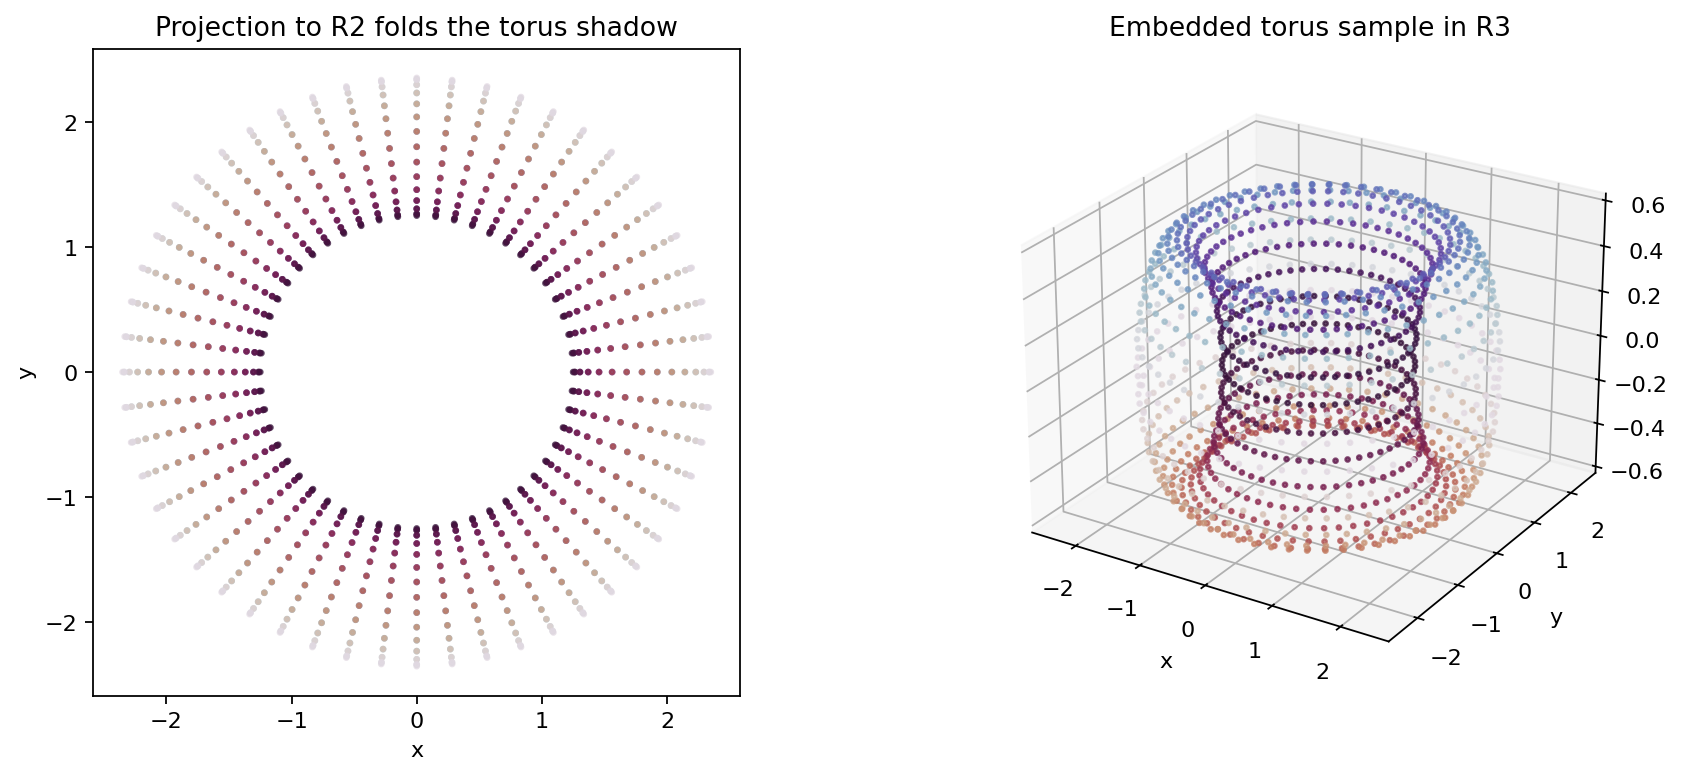

{'projection_R2_near_collisions': 0,
 'embedding_R3_near_collisions': 0,
 'feature_embedding_R5_near_collisions': 0}

In [5]:
# Projection experiment for an embedded torus in R3 and a feature embedding in R5.
nu, nv = 52, 28
u_vals = np.linspace(0, 2*np.pi, nu, endpoint=False)
v_vals = np.linspace(0, 2*np.pi, nv, endpoint=False)
UU, VV = np.meshgrid(u_vals, v_vals, indexing="ij")
R, r = 1.8, 0.55
X3 = np.column_stack([
    ((R + r*np.cos(VV))*np.cos(UU)).ravel(),
    ((R + r*np.cos(VV))*np.sin(UU)).ravel(),
    (r*np.sin(VV)).ravel(),
])
X2 = X3[:, :2]
X5 = np.column_stack([X3, np.cos(2*UU).ravel(), np.sin(2*VV).ravel()])

def near_collision_count(points, threshold):
    # A deterministic subsample keeps the O(n^2) diagnostic light enough for nbclient.
    sample = points[::4]
    count = 0
    min_dist = float("inf")
    for i in range(len(sample)):
        diffs = sample[i+1:] - sample[i]
        if len(diffs) == 0:
            continue
        d = np.linalg.norm(diffs, axis=1)
        min_dist = min(min_dist, float(d.min()))
        count += int(np.sum((d > 1e-9) & (d < threshold)))
    return count, min_dist

collisions = {
    "projection_R2_near_collisions": near_collision_count(X2, 0.075)[0],
    "embedding_R3_near_collisions": near_collision_count(X3, 0.075)[0],
    "feature_embedding_R5_near_collisions": near_collision_count(X5, 0.075)[0],
}

fig = plt.figure(figsize=(12, 5))
ax0 = fig.add_subplot(121)
ax0.scatter(X2[:, 0], X2[:, 1], s=4, c=VV.ravel(), cmap="twilight", alpha=0.75)
ax0.set_aspect("equal", adjustable="box")
ax0.set_title("Projection to R2 folds the torus shadow")
ax0.set_xlabel("x")
ax0.set_ylabel("y")
ax1 = fig.add_subplot(122, projection="3d")
ax1.scatter(X3[:, 0], X3[:, 1], X3[:, 2], s=4, c=VV.ravel(), cmap="twilight", alpha=0.75)
ax1.set_title("Embedded torus sample in R3")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
ax1.view_init(elev=25, azim=-58)
fig.tight_layout()
embed_path = save_matplotlib(fig, FIGURES / "embedding-projection-collision-lab.png")
plt.close(fig)
embed_json = save_json(collisions, CHECKS / "embedding-projection-collision-lab.json")
TRACKED_ARTIFACTS.extend([embed_path, embed_json])
display_artifact(embed_path, width=840)
collisions


## Applied Lab: Reading A Smooth Map Like A Topologist

Use the three diagnostics together. First ask whether a chart or parametrization has the expected rank. If not, the object may fail to be a manifold at that point, or the parametrization may be hiding a singularity. Second ask whether a map is locally one of the canonical models supplied by the inverse, immersion, or submersion theorem. This is where dimension enters: injective and surjective derivative conditions have different geometric consequences. Third ask whether a target value or target submanifold is regular or transverse. Regularity is not just a technical hypothesis; it is the bridge from smooth maps to new manifolds.

The chapter also introduces a habit used throughout differential topology: perturb when a condition is generic, but measure what the perturbation is supposed to fix. The saved HTML level-set lab records the exceptional critical value. The rank table records the exact linear algebra. The projection lab records how a visual shadow can lie unless the ambient coordinates are rich enough. These are the chapter's main proof moves expressed as computational checks: rank, regularity, transversality, stability, and embedding dimension.


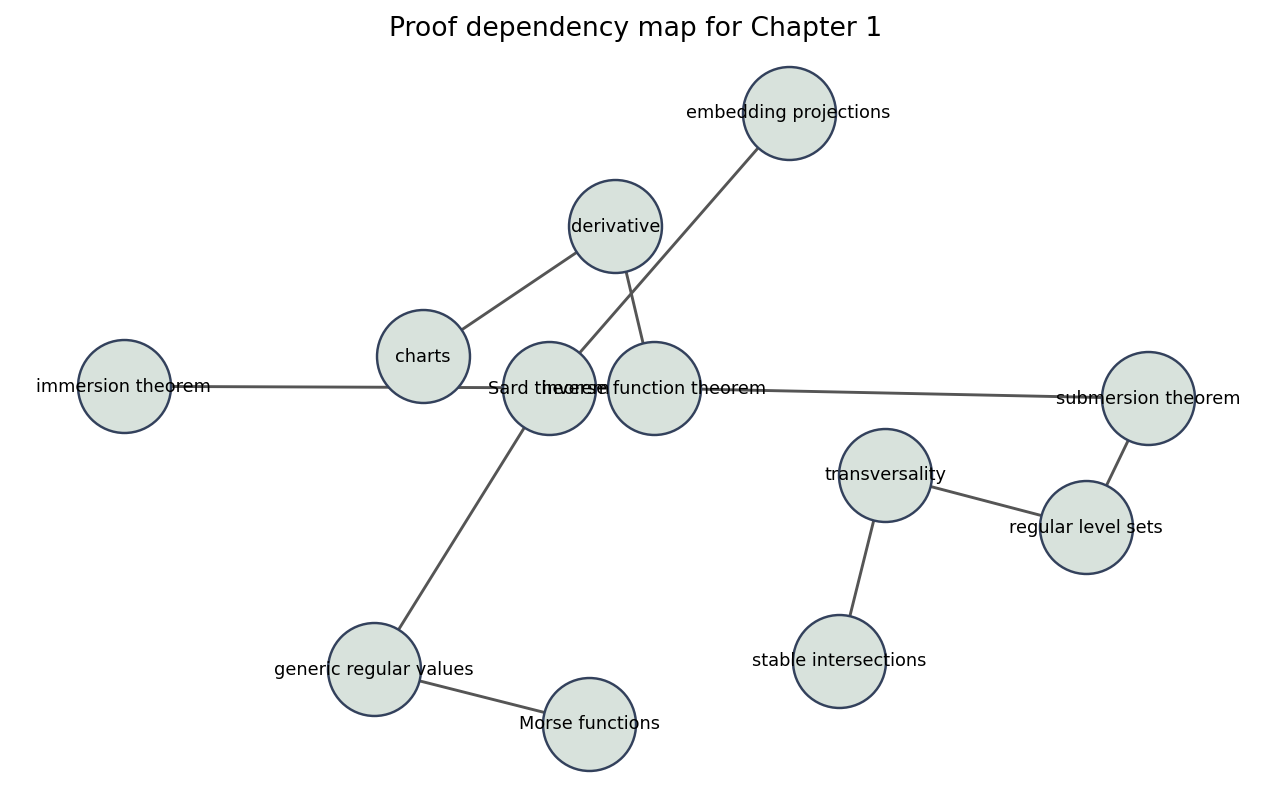

{'node_count': 12, 'edge_count': 10, 'acyclic': True}

In [6]:
# Proof-dependency view for the chapter's logic.
G = nx.DiGraph()
edges = [
    ("charts", "derivative"),
    ("derivative", "inverse function theorem"),
    ("inverse function theorem", "immersion theorem"),
    ("inverse function theorem", "submersion theorem"),
    ("submersion theorem", "regular level sets"),
    ("regular level sets", "transversality"),
    ("Sard theorem", "generic regular values"),
    ("generic regular values", "Morse functions"),
    ("Sard theorem", "embedding projections"),
    ("transversality", "stable intersections"),
]
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=11, k=0.9)
fig, ax = plt.subplots(figsize=(10, 6))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.3, edge_color="#555555")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#d8e2dc", edgecolors="#33415c", linewidths=1.1, node_size=1750)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title("Proof dependency map for Chapter 1")
ax.axis("off")
dep_path = save_matplotlib(fig, FIGURES / "chapter-logic-rank-regularity-dependencies.png")
plt.close(fig)
dep_json = save_json({"nodes": list(G.nodes), "edges": edges, "acyclic": nx.is_directed_acyclic_graph(G)}, CHECKS / "chapter-logic-rank-regularity-dependencies.json")
TRACKED_ARTIFACTS.extend([dep_path, dep_json])
display_artifact(dep_path, width=760)
{"node_count": G.number_of_nodes(), "edge_count": G.number_of_edges(), "acyclic": nx.is_directed_acyclic_graph(G)}


In [7]:
assert chart_check["rank"] == 2
assert chart_check["area_scale"] > 0.9
assert chart_check["finite_difference_residual"] < 1e-4
assert rank_rows[0]["rank_value"] == 1
assert rank_rows[1]["rank_value"] == 1
assert abs(transverse_det) > 1e-3
assert morse_check["nondegenerate"]
assert morse_check["minimum_gradient_norm_on_regular_circles"] > 0
assert collisions["projection_R2_near_collisions"] >= collisions["embedding_R3_near_collisions"]
assert_artifacts(TRACKED_ARTIFACTS, min_bytes=80)
final_sanity = {
    "unit": UNIT_KEY,
    "tracked_artifacts": len(TRACKED_ARTIFACTS),
    "core_checks": ["rank(J)=2", "transverse determinant nonzero", "Morse critical points nondegenerate", "projection collisions measured"],
}
final_sanity


{'unit': 'chapter-01-manifolds-and-smooth-maps',
 'tracked_artifacts': 11,
 'core_checks': ['rank(J)=2',
  'transverse determinant nonzero',
  'Morse critical points nondegenerate',
  'projection collisions measured']}

## Takeaways

A smooth manifold is locally computable through charts, but the geometric object is not the chart. The derivative is the chapter's central instrument: it detects local invertibility, immersions, submersions, regular values, and transverse intersections. Sard's theorem explains why regularity is a useful working condition rather than a rare accident. Morse functions give a controlled way to turn global topology into isolated critical data. Embedding and projection results show why abstract manifolds can be studied concretely in Euclidean space while still requiring attention to dimension.

For later chapters, keep the following checklist: choose local coordinates, compute the derivative, read its rank, inspect the relevant tangent spaces, and record the invariant that should survive perturbation. That checklist is the computational version of the chapter's language.
